## 16. Resource Extraction

# MESSAGEix-Pakistan - Model Output Charts

In [55]:
import pandas as pd
import pyam
import matplotlib.pyplot as plt
import numpy as np

_raw = pd.read_excel('data/MESSAGEix-Pakistan_NEW-NZ.xlsx')
_raw.columns = _raw.columns.astype(str)
_raw = _raw.loc[:, ~_raw.columns.str.lower().str.startswith('unnamed:')]
msg = pyam.IamDataFrame(_raw)

MODELS = [('MSG', msg)]
YEARS = [2025, 2030, 2035, 2040, 2045, 2050, 2055, 2060, 2070]

In [56]:
def stacked_bar_comparison(variables, colors, labels, title, ylabel='Energy (PJ)', scale=1000, years=YEARS):
    """Side-by-side stacked bars: MESSAGE vs GCAM for each year."""
    fig, ax = plt.subplots(figsize=(14, 7))
    w, gap_year, gap_model = 0.9, 1.5, 0.1
    added, x = set(), 0
    year_centers = []
    bar_positions = []
    bar_labels = []

    for yi, year in enumerate(years):
        if yi > 0:
            x += gap_year
        pair_start = x
        for mi, (mname, mdf) in enumerate(MODELS):
            bottom = 0
            for var in variables:
                filt = mdf.filter(variable=var, year=year)
                val = filt.timeseries().values[0][0] * scale if not filt.empty else 0
                if val <= 0:
                    continue
                lbl = labels[var] if labels[var] not in added else ''
                if lbl:
                    added.add(labels[var])
                ax.bar(x, val, w, bottom=bottom, color=colors[var], label=lbl)
                bottom += val
            bar_positions.append(x)
            bar_labels.append(mname)
            x += w + gap_model
        year_centers.append((pair_start + x - w - gap_model) / 2)

    # Model names as x-tick labels
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels, fontsize=12)
    # Year labels below
    for center, year in zip(year_centers, years):
        ax.text(center, -0.09, str(year), transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=14)

    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16, pad=60)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper center', ncol=min(len(variables), 6), fontsize=12,
              frameon=True, bbox_to_anchor=(0.5, 1.12))
    plt.tight_layout()
    plt.show()

## 1. Emissions - Kyoto Gases

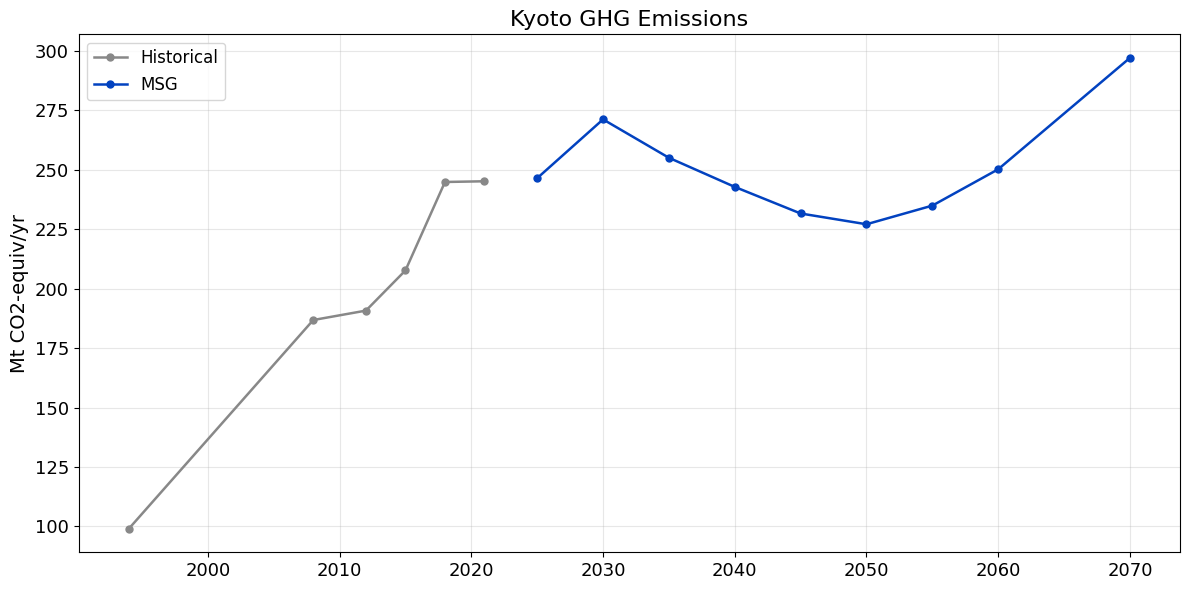

In [57]:
fig, ax = plt.subplots(figsize=(12, 6))

# Historical
ext_years  = [1994, 2008, 2012, 2015, 2018, 2021]
ext_values = [99.0265, 186.8265, 190.791, 207.7, 244.9, 245.2]
ax.plot(ext_years, ext_values, color='#888888', marker='o', markersize=5,
        linestyle='-', linewidth=1.8, label='Historical')

ts = msg.filter(variable='Emissions|Kyoto Gases').timeseries()
if not ts.empty:
    years_ts = ts.columns.astype(int)
    mask = years_ts <= 2070
    ax.plot(years_ts[mask], ts.values[0][mask], color='#0242C0', marker='o',
            markersize=5, linestyle='-', linewidth=1.8, label='MSG')

ax.set_ylabel('Mt CO2-equiv/yr', fontsize=14)
ax.set_title('Kyoto GHG Emissions', fontsize=16)
ax.legend(fontsize=12)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Electricity Generation Mix (Secondary Energy)

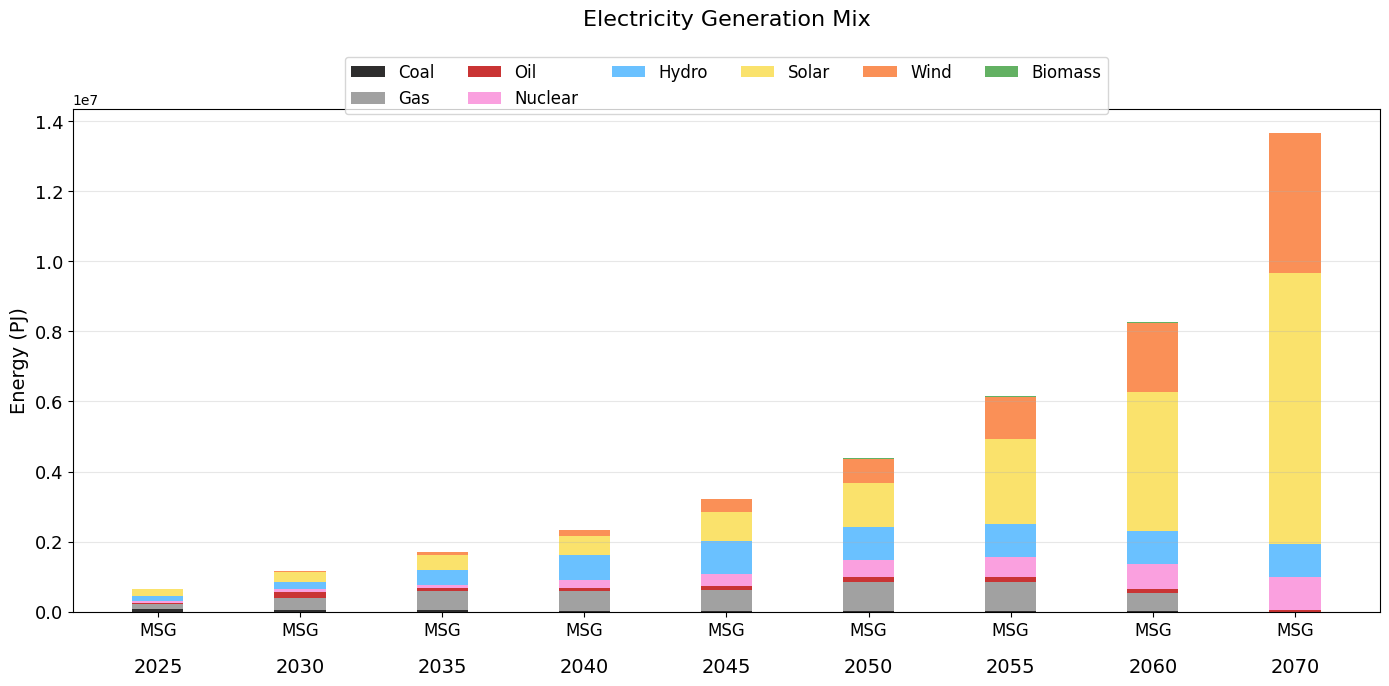

In [58]:
vars_SE = [
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Other',
]
colors_SE = {
    'Secondary Energy|Electricity|Coal': '#2E2D2D',
    'Secondary Energy|Electricity|Gas': '#A1A1A1',
    'Secondary Energy|Electricity|Oil': '#c93434',
    'Secondary Energy|Electricity|Nuclear': '#faa0df',
    'Secondary Energy|Electricity|Hydro': '#6ac1ff',
    'Secondary Energy|Electricity|Solar': '#fae26c',
    'Secondary Energy|Electricity|Wind': '#fa9057',
    'Secondary Energy|Electricity|Biomass': '#63b163',
    'Secondary Energy|Electricity|Geothermal': '#9e9e9e',
    'Secondary Energy|Electricity|Other': '#bdbdbd',
}
labels_SE = {v: v.split('|')[-1] for v in vars_SE}

stacked_bar_comparison(vars_SE, colors_SE, labels_SE, 'Electricity Generation Mix')

## 3. Final Energy - Industry

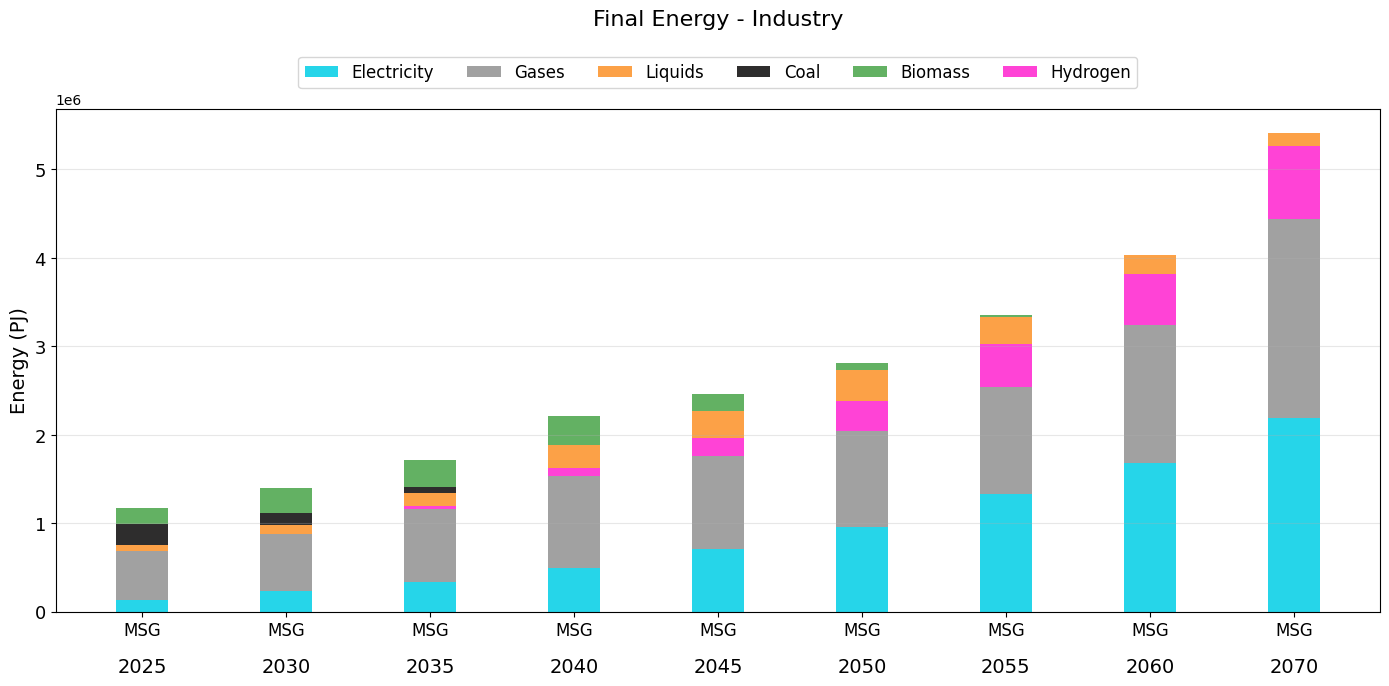

In [59]:
vars_FE_ind = [
    'Final Energy|Industry|Electricity',
    'Final Energy|Industry|Gases',
    'Final Energy|Industry|Hydrogen',
    'Final Energy|Industry|Liquids',
    'Final Energy|Industry|Solids|Coal',
    'Final Energy|Industry|Solids|Biomass',
]
colors_FE_ind = {
    'Final Energy|Industry|Electricity': '#26d5e9',
    'Final Energy|Industry|Gases': '#a1a1a1',
    'Final Energy|Industry|Hydrogen': '#FF43D6',
    'Final Energy|Industry|Liquids': '#FCA147',
    'Final Energy|Industry|Solids|Coal': '#2E2D2D',
    'Final Energy|Industry|Solids|Biomass': '#63b163',
}
labels_FE_ind = {v: v.split('|')[-1] for v in vars_FE_ind}

stacked_bar_comparison(vars_FE_ind, colors_FE_ind, labels_FE_ind,
                       'Final Energy - Industry')

## 4. Final Energy - Residential & Commercial

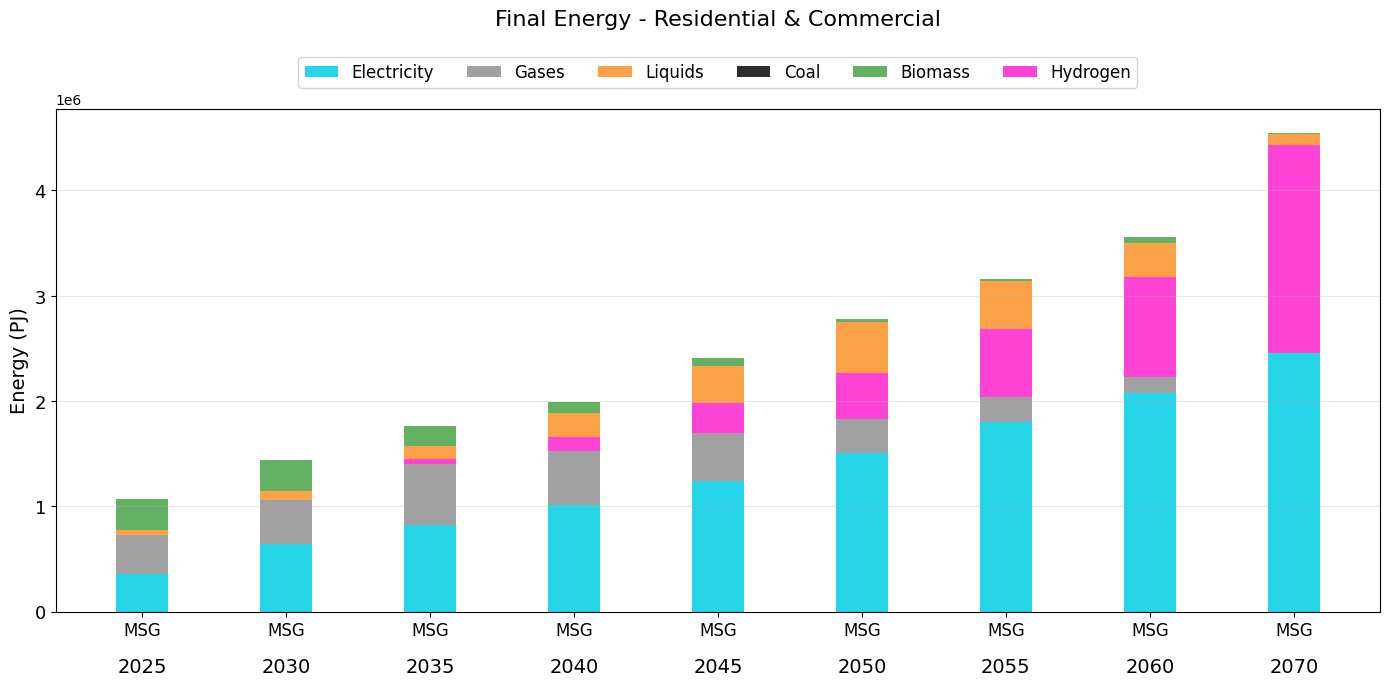

In [60]:
vars_FE_rc = [
    'Final Energy|Residential and Commercial|Electricity',
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Hydrogen',
    'Final Energy|Residential and Commercial|Liquids',
    'Final Energy|Residential and Commercial|Other',
    'Final Energy|Residential and Commercial|Solids|Coal',
    'Final Energy|Residential and Commercial|Solids|Biomass',
]
colors_FE_rc = {
    'Final Energy|Residential and Commercial|Electricity': '#26d5e9',
    'Final Energy|Residential and Commercial|Gases': '#a1a1a1',
    'Final Energy|Residential and Commercial|Hydrogen': '#FF43D6',
    'Final Energy|Residential and Commercial|Liquids': '#FCA147',
    'Final Energy|Residential and Commercial|Other': '#bdbdbd',
    'Final Energy|Residential and Commercial|Solids|Coal': '#2E2D2D',
    'Final Energy|Residential and Commercial|Solids|Biomass': '#63b163',
}
labels_FE_rc = {v: v.split('|')[-1] for v in vars_FE_rc}

stacked_bar_comparison(vars_FE_rc, colors_FE_rc, labels_FE_rc,
                       'Final Energy - Residential & Commercial')

## 5. Final Energy - Transportation

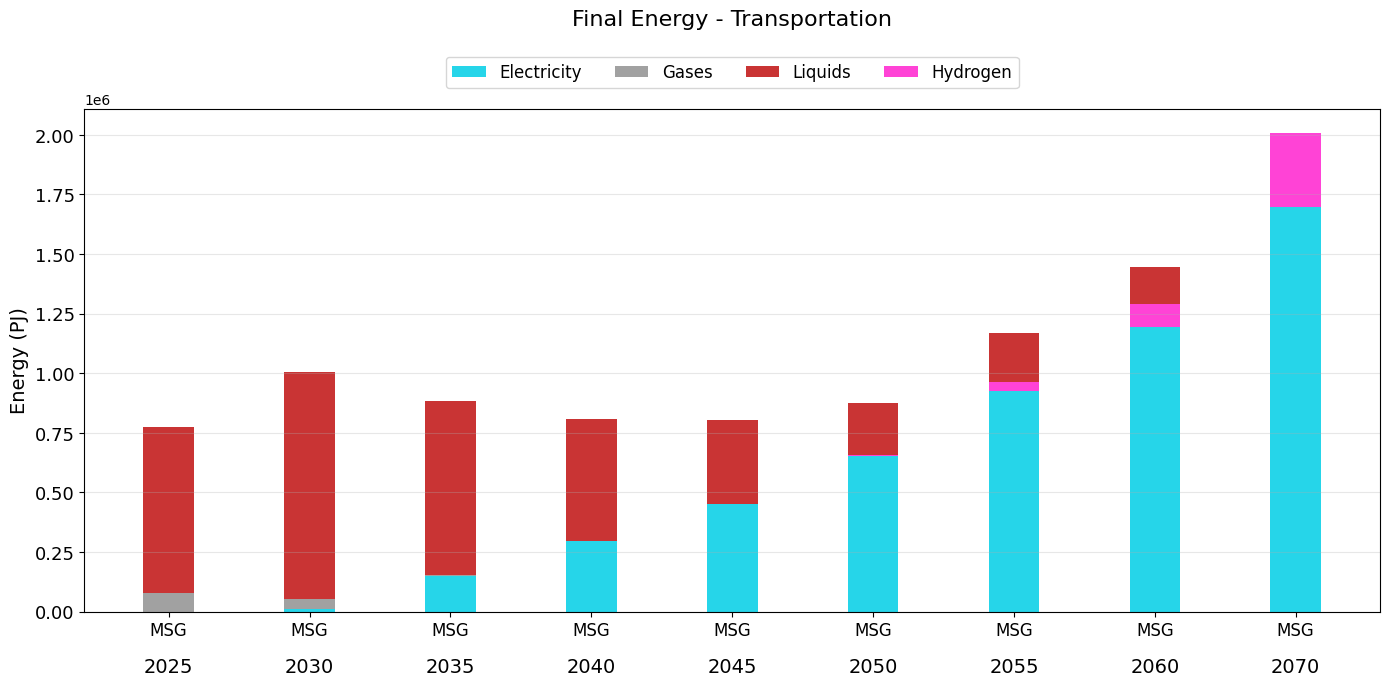

In [61]:
vars_FE_tr = [
    'Final Energy|Transportation|Electricity',
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Hydrogen',
    'Final Energy|Transportation|Liquids',
    'Final Energy|Transportation|Other',
]
colors_FE_tr = {
    'Final Energy|Transportation|Electricity': '#26d5e9',
    'Final Energy|Transportation|Gases': '#a1a1a1',
    'Final Energy|Transportation|Hydrogen': '#FF43D6',
    'Final Energy|Transportation|Liquids': '#c93434',
    'Final Energy|Transportation|Other': '#fae26c',
}
labels_FE_tr = {v: v.split('|')[-1] for v in vars_FE_tr}

stacked_bar_comparison(vars_FE_tr, colors_FE_tr, labels_FE_tr,
                       'Final Energy - Transportation')

## 6. Electricity Capacity

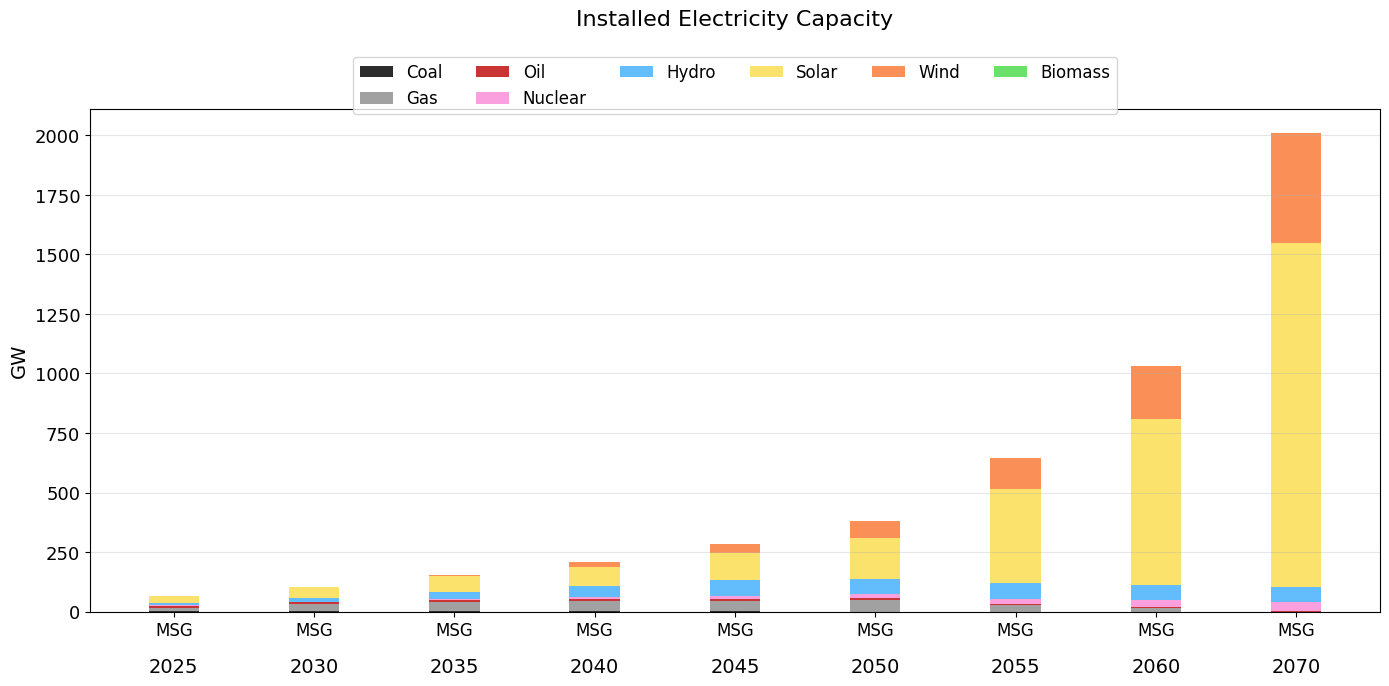

In [62]:
vars_cap = [
    'Capacity|Electricity|Coal',
    'Capacity|Electricity|Gas',
    'Capacity|Electricity|Oil',
    'Capacity|Electricity|Nuclear',
    'Capacity|Electricity|Hydro',
    'Capacity|Electricity|Solar',
    'Capacity|Electricity|Wind',
    'Capacity|Electricity|Biomass',
    'Capacity|Electricity|Geothermal',
]
colors_cap = {
    'Capacity|Electricity|Coal': '#2E2D2D',
    'Capacity|Electricity|Gas': '#A1A1A1',
    'Capacity|Electricity|Oil': '#c93434',
    'Capacity|Electricity|Nuclear': '#faa0df',
    'Capacity|Electricity|Hydro': "#63bcfc",
    'Capacity|Electricity|Solar': '#fae26c',
    'Capacity|Electricity|Wind': '#fa9057',
    'Capacity|Electricity|Biomass': "#6be06b",
    'Capacity|Electricity|Geothermal': "#7c89c5",
}
labels_cap = {v: v.split('|')[-1] for v in vars_cap}

stacked_bar_comparison(vars_cap, colors_cap, labels_cap,
                       'Installed Electricity Capacity', ylabel='GW', scale=1)

## 7. CO2 Emissions by Demand Sector

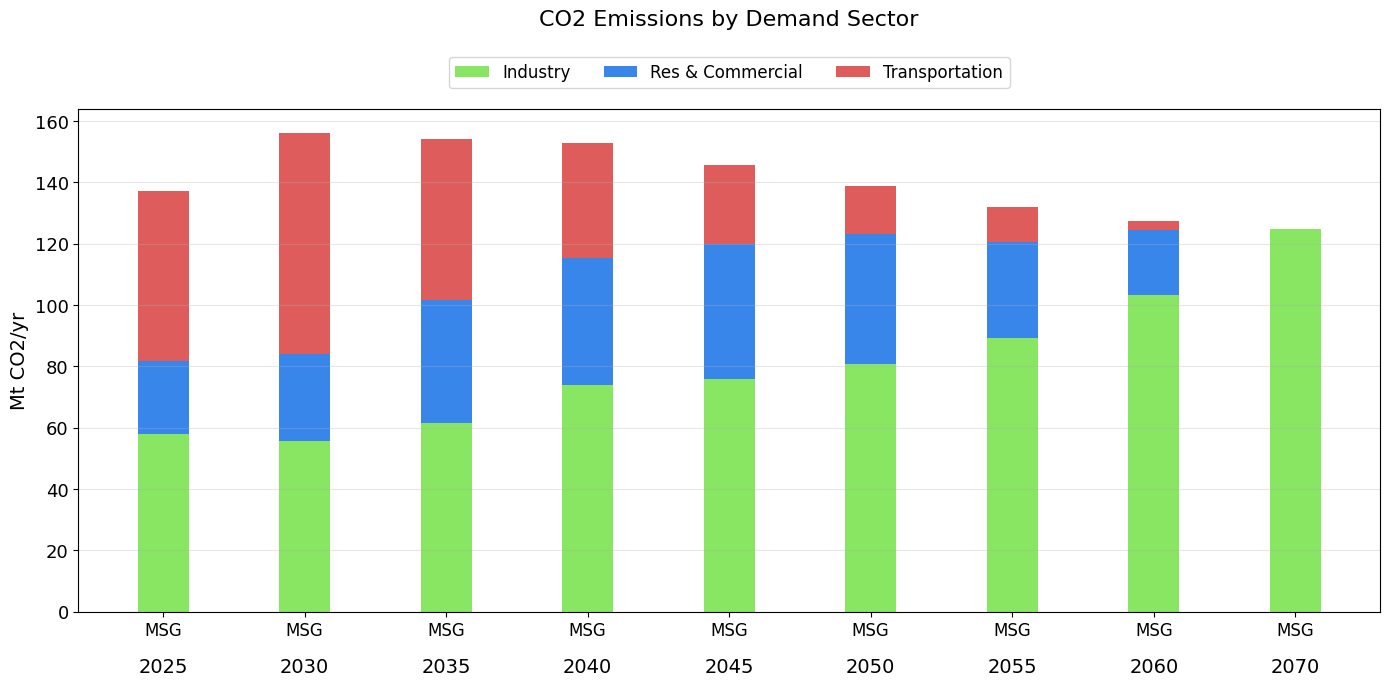

In [63]:
cats = ['Industry', 'Res & Commercial', 'Transportation']
cat_colors = {'Industry': '#88E663', 'Res & Commercial': '#3986eb', 'Transportation': '#df5c5c'}

cat_vars = {
    'MSG': {
        'Industry':         ['Emissions|CO2|Energy|Demand|Industry',
                             'Emissions|CO2|Energy|Demand|Other Sector'],
        'Res & Commercial': ['Emissions|CO2|Energy|Demand|Residential and Commercial'],
        'Transportation':   ['Emissions|CO2|Energy|Demand|Transportation'],
    },
}

fig, ax = plt.subplots(figsize=(14, 7))
w, gap_year, gap_model = 0.9, 1.5, 0.1
added, x = set(), 0
year_centers, bar_positions, bar_labels = [], [], []

for yi, year in enumerate(YEARS):
    if yi > 0:
        x += gap_year
    pair_start = x
    for mname, mdf in MODELS:
        bottom = 0
        for cat in cats:
            val = 0
            for var in cat_vars[mname][cat]:
                filt = mdf.filter(variable=var, year=year)
                if not filt.empty:
                    val += filt.timeseries().values[0][0]
            if val <= 0:
                continue
            lbl = cat if cat not in added else ''
            if lbl:
                added.add(cat)
            ax.bar(x, val, w, bottom=bottom, color=cat_colors[cat], label=lbl)
            bottom += val
        bar_positions.append(x)
        bar_labels.append(mname)
        x += w + gap_model
    year_centers.append((pair_start + x - w - gap_model) / 2)

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, fontsize=12)
for center, year in zip(year_centers, YEARS):
    ax.text(center, -0.09, str(year), transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14)

ax.set_ylabel('Mt CO2/yr', fontsize=14)
ax.set_title('CO2 Emissions by Demand Sector', fontsize=16, pad=60)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', ncol=3, fontsize=12,
          frameon=True, bbox_to_anchor=(0.5, 1.12))
plt.tight_layout()
plt.show()

## 8. CO2 Emissions by Energy Supply

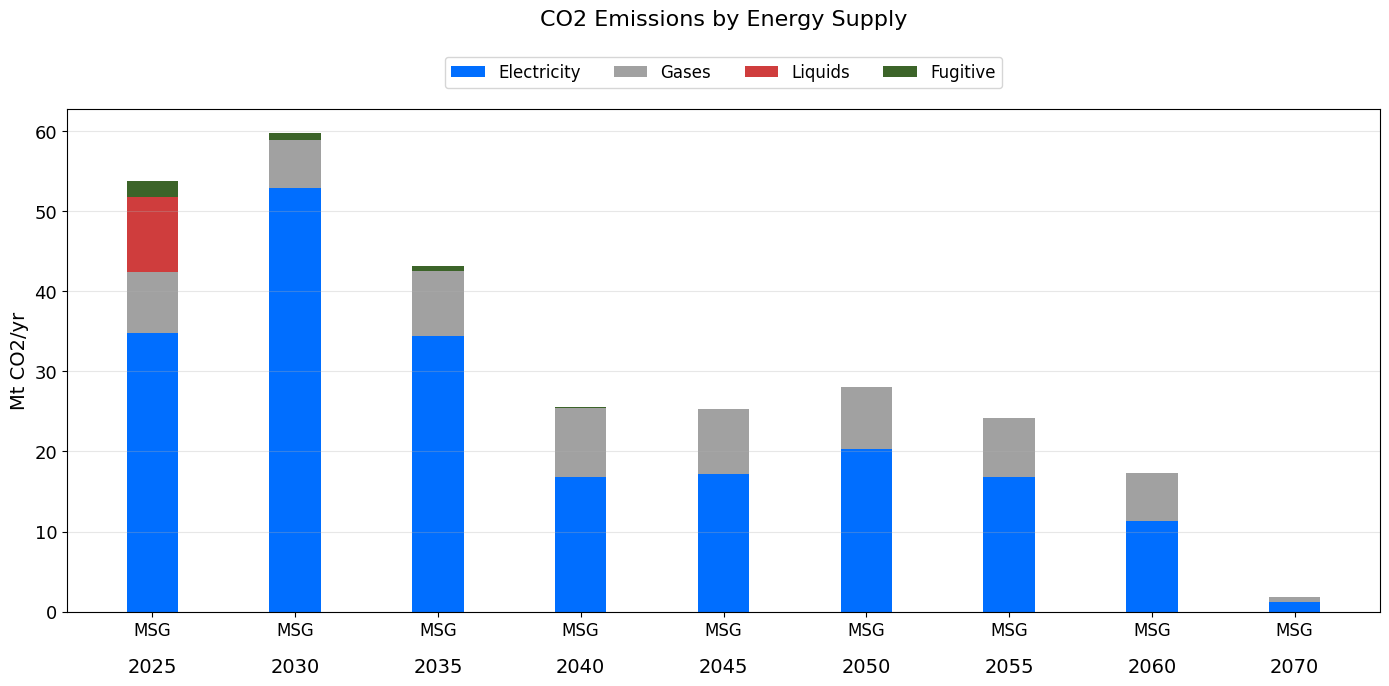

In [64]:
vars_co2_supply = [
    'Emissions|CO2|Energy|Supply|Electricity',
    'Emissions|CO2|Energy|Supply|Gases',
    'Emissions|CO2|Energy|Supply|Liquids',
    'Emissions|CO2|Energy|Supply|Fugitive',
]
colors_co2_supply = {
    'Emissions|CO2|Energy|Supply|Electricity': "#006eff",
    'Emissions|CO2|Energy|Supply|Gases': "#a1a1a1",
    'Emissions|CO2|Energy|Supply|Liquids': "#cf3d3d",
    'Emissions|CO2|Energy|Supply|Fugitive': "#3C6429",
}
labels_co2_supply = {
    'Emissions|CO2|Energy|Supply|Electricity': 'Electricity',
    'Emissions|CO2|Energy|Supply|Gases': 'Gases',
    'Emissions|CO2|Energy|Supply|Liquids': 'Liquids',
    'Emissions|CO2|Energy|Supply|Fugitive': 'Fugitive',
}

stacked_bar_comparison(vars_co2_supply, colors_co2_supply, labels_co2_supply,
                       'CO2 Emissions by Energy Supply', ylabel='Mt CO2/yr', scale=1)

## 9. Emissions by Pollutant - Energy

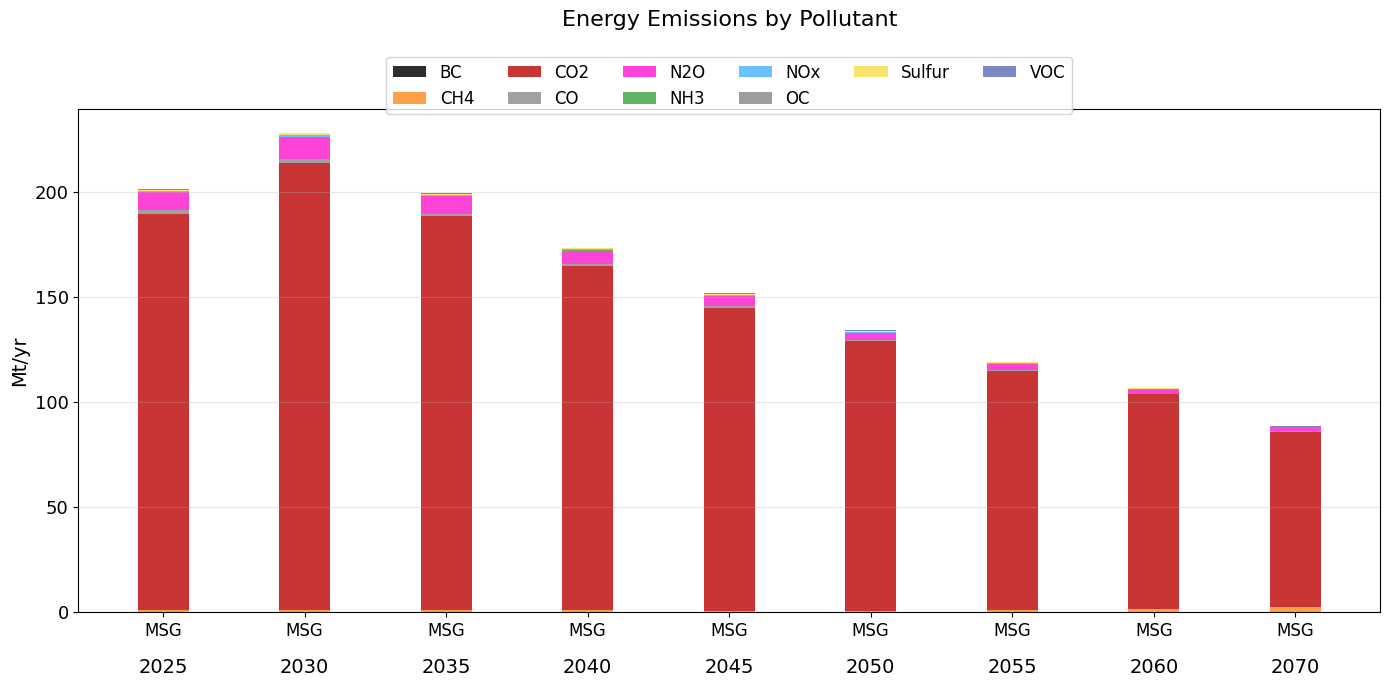

In [65]:
pollutant_colors = {
    'BC': '#2E2D2D', 'CH4': '#FCA147', 'CO2': '#c93434', 'CO': '#a1a1a1',
    'N2O': '#FF43D6', 'NH3': '#63b163', 'NOx': '#6ac1ff', 'OC': '#9e9e9e',
    'Sulfur': '#fae26c', 'VOC': '#7c89c5',
}

vars_energy = [
    'Emissions|BC|Energy', 'Emissions|CH4|Energy', 'Emissions|CO2|Energy',
    'Emissions|CO|Energy', 'Emissions|N2O|Energy', 'Emissions|NH3|Energy',
    'Emissions|NOx|Energy', 'Emissions|OC|Energy', 'Emissions|Sulfur|Energy',
    'Emissions|VOC|Energy',
]
colors_energy = {v: pollutant_colors[v.split('|')[1]] for v in vars_energy}
labels_energy = {v: v.split('|')[1] for v in vars_energy}

stacked_bar_comparison(vars_energy, colors_energy, labels_energy,
                       'Energy Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 10. Emissions by Pollutant - Industrial Processes

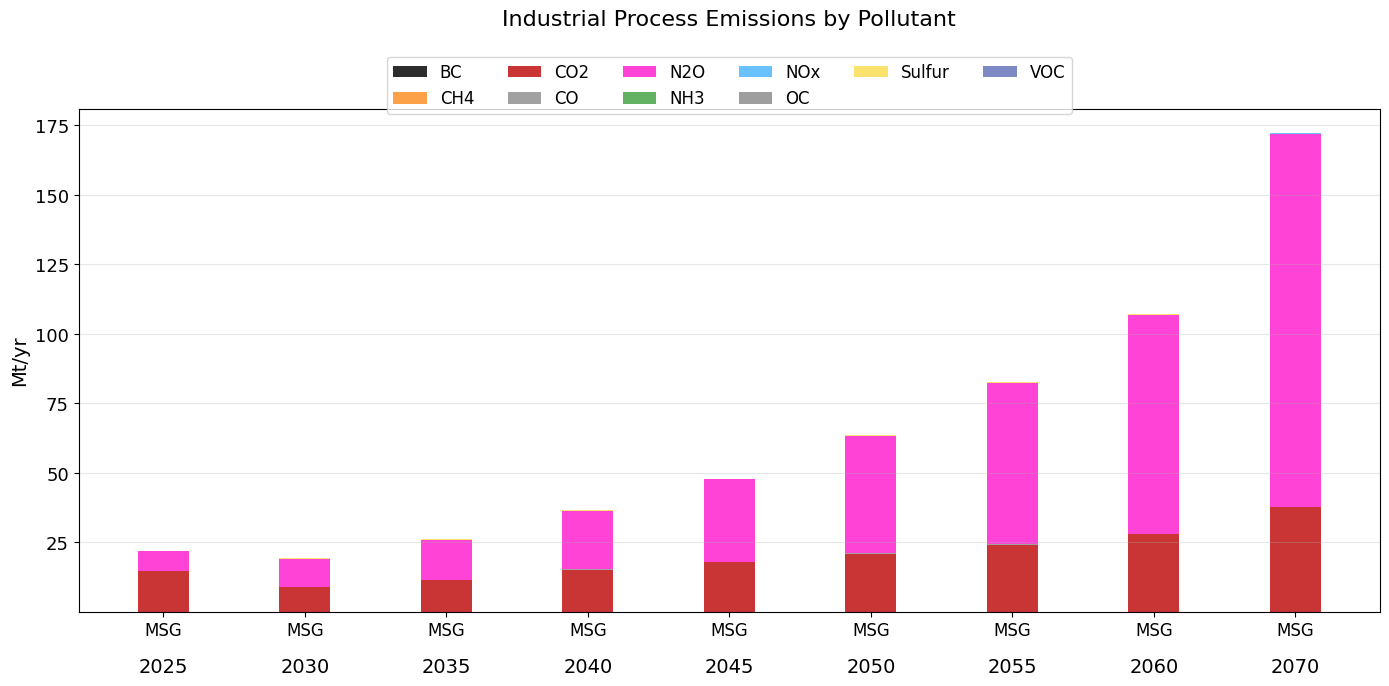

In [66]:
vars_indproc = [
    'Emissions|BC|Industrial Processes', 'Emissions|CH4|Industrial Processes',
    'Emissions|CO2|Industrial Processes', 'Emissions|CO|Industrial Processes',
    'Emissions|N2O|Industrial Processes', 'Emissions|NH3|Industrial Processes',
    'Emissions|NOx|Industrial Processes', 'Emissions|OC|Industrial Processes',
    'Emissions|Sulfur|Industrial Processes', 'Emissions|VOC|Industrial Processes',
]
colors_indproc = {v: pollutant_colors[v.split('|')[1]] for v in vars_indproc}
labels_indproc = {v: v.split('|')[1] for v in vars_indproc}

stacked_bar_comparison(vars_indproc, colors_indproc, labels_indproc,
                       'Industrial Process Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 11. Emissions by Pollutant - Waste

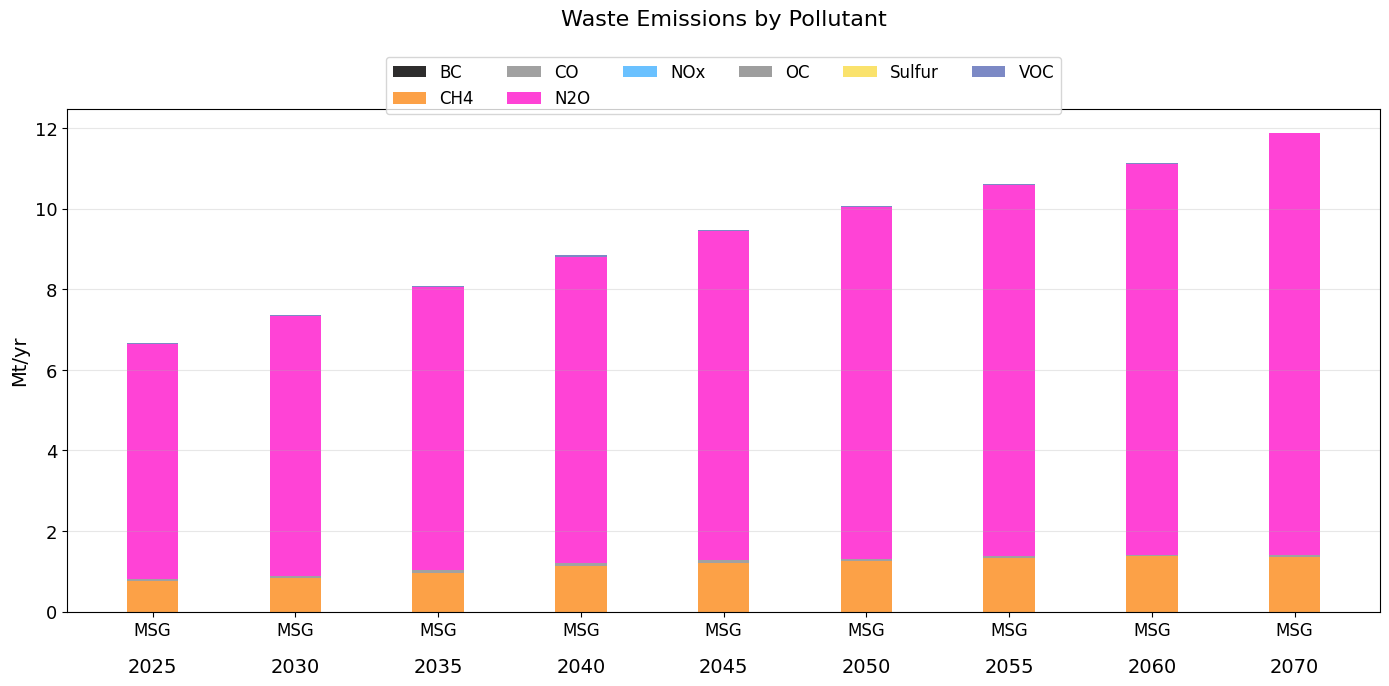

In [67]:
vars_waste = [
    'Emissions|BC|Waste', 'Emissions|CH4|Waste', 'Emissions|CO|Waste',
    'Emissions|N2O|Waste', 'Emissions|NOx|Waste', 'Emissions|OC|Waste',
    'Emissions|Sulfur|Waste', 'Emissions|VOC|Waste',
]
colors_waste = {v: pollutant_colors[v.split('|')[1]] for v in vars_waste}
labels_waste = {v: v.split('|')[1] for v in vars_waste}

stacked_bar_comparison(vars_waste, colors_waste, labels_waste,
                       'Waste Emissions by Pollutant', ylabel='Mt/yr', scale=1)

## 12. Total Final Energy by Fuel

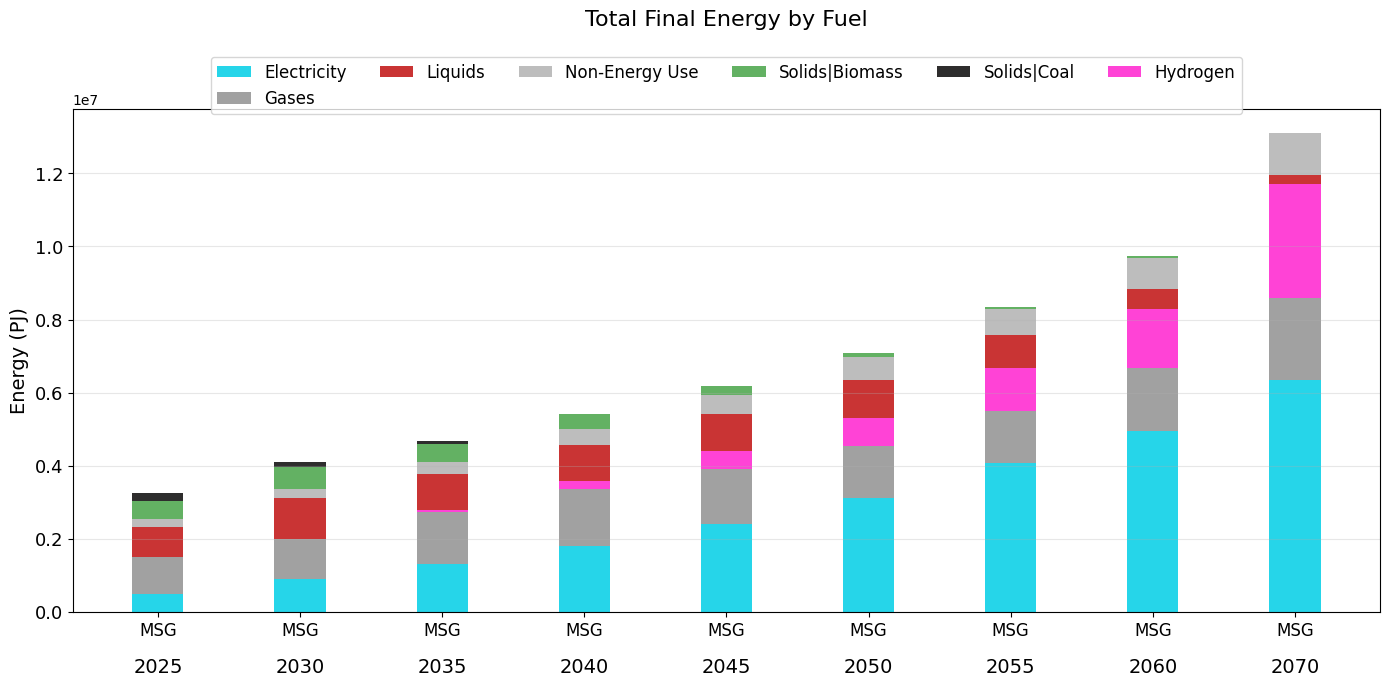

In [68]:
vars_FE_total = [
    'Final Energy|Electricity',
    'Final Energy|Gases',
    'Final Energy|Hydrogen',
    'Final Energy|Liquids',
    'Final Energy|Non-Energy Use',
    'Final Energy|Solids|Biomass',
    'Final Energy|Solids|Coal',
]
colors_FE_total = {
    'Final Energy|Electricity': '#26d5e9',
    'Final Energy|Gases': '#a1a1a1',
    'Final Energy|Hydrogen': '#FF43D6',
    'Final Energy|Liquids': '#c93434',
    'Final Energy|Non-Energy Use': '#bdbdbd',
    'Final Energy|Solids|Biomass': '#63b163',
    'Final Energy|Solids|Coal': '#2E2D2D',
}
labels_FE_total = {v: v.replace('Final Energy|', '') for v in vars_FE_total}

stacked_bar_comparison(vars_FE_total, colors_FE_total, labels_FE_total,
                       'Total Final Energy by Fuel')

## 13. Primary Energy Mix

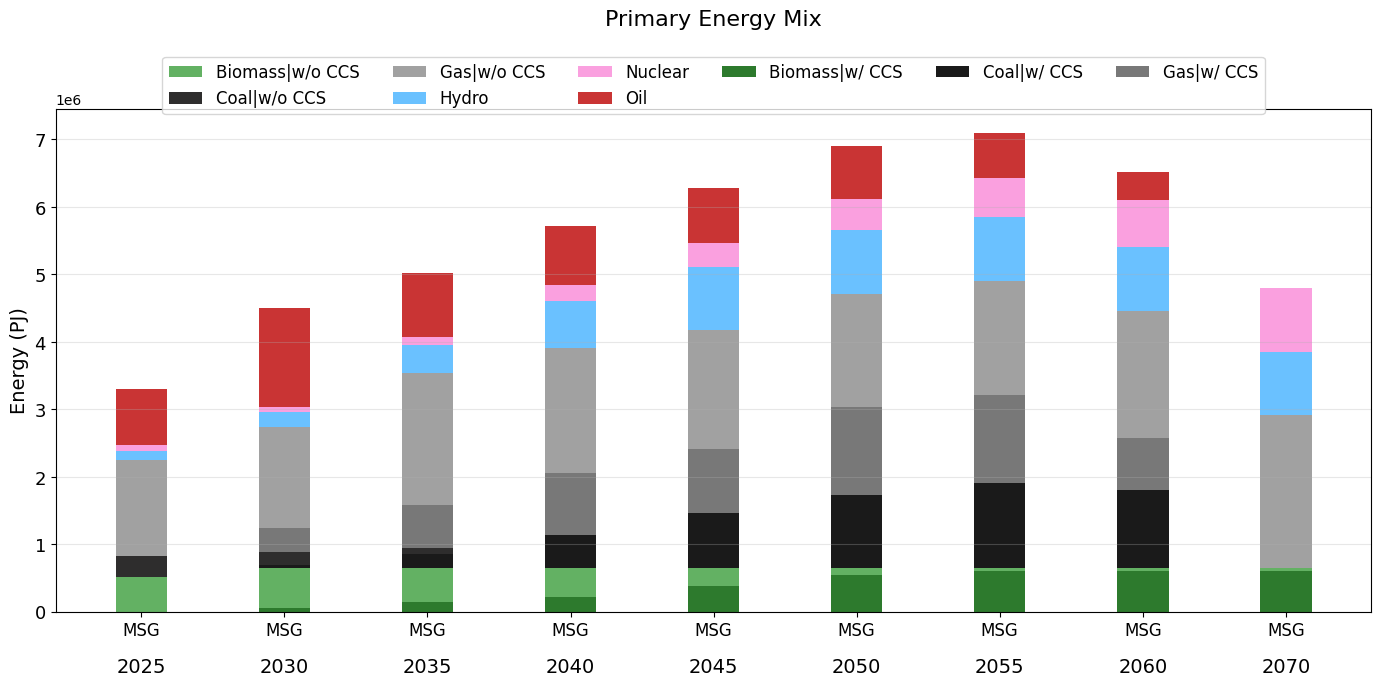

In [69]:
vars_PE = [
    'Primary Energy|Biomass|w/ CCS',
    'Primary Energy|Biomass|w/o CCS',
    'Primary Energy|Coal|w/ CCS',
    'Primary Energy|Coal|w/o CCS',
    'Primary Energy|Gas|w/ CCS',
    'Primary Energy|Gas|w/o CCS',
    'Primary Energy|Geothermal',
    'Primary Energy|Hydro',
    'Primary Energy|Nuclear',
    'Primary Energy|Ocean',
    'Primary Energy|Oil',
    'Primary Energy|Other',
]
colors_PE = {
    'Primary Energy|Biomass|w/ CCS':  '#2d7a2d',
    'Primary Energy|Biomass|w/o CCS': '#63b163',
    'Primary Energy|Coal|w/ CCS':     '#1a1a1a',
    'Primary Energy|Coal|w/o CCS':    '#2E2D2D',
    'Primary Energy|Gas|w/ CCS':      '#787878',
    'Primary Energy|Gas|w/o CCS':     '#A1A1A1',
    'Primary Energy|Geothermal':      '#7c89c5',
    'Primary Energy|Hydro':           '#6ac1ff',
    'Primary Energy|Nuclear':         '#faa0df',
    'Primary Energy|Ocean':           '#26d5e9',
    'Primary Energy|Oil':             '#c93434',
    'Primary Energy|Other':           '#bdbdbd',
}
labels_PE = {v: v.replace('Primary Energy|', '') for v in vars_PE}

stacked_bar_comparison(vars_PE, colors_PE, labels_PE, 'Primary Energy Mix')

## 14. Trade - Primary Energy Volumes

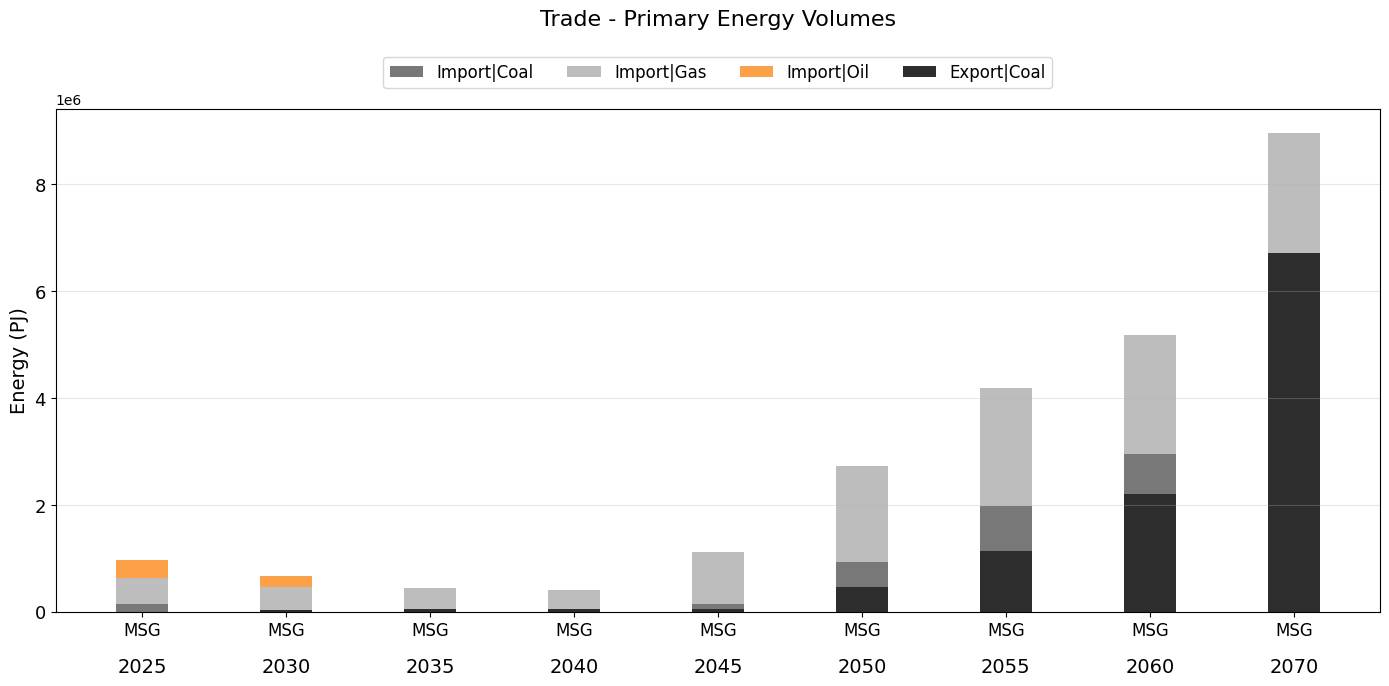

In [70]:
vars_trade_PE = [
    'Trade|Gross Export|Primary Energy|Biomass|Volume',
    'Trade|Gross Export|Primary Energy|Coal|Volume',
    'Trade|Gross Export|Primary Energy|Gas|Volume',
    'Trade|Gross Export|Primary Energy|Oil|Volume',
    'Trade|Gross Import|Primary Energy|Biomass|Volume',
    'Trade|Gross Import|Primary Energy|Coal|Volume',
    'Trade|Gross Import|Primary Energy|Gas|Volume',
    'Trade|Gross Import|Primary Energy|Oil|Volume',
]
colors_trade_PE = {
    'Trade|Gross Export|Primary Energy|Biomass|Volume': '#2d7a2d',
    'Trade|Gross Export|Primary Energy|Coal|Volume':    '#2E2D2D',
    'Trade|Gross Export|Primary Energy|Gas|Volume':     '#A1A1A1',
    'Trade|Gross Export|Primary Energy|Oil|Volume':     '#c93434',
    'Trade|Gross Import|Primary Energy|Biomass|Volume': '#63b163',
    'Trade|Gross Import|Primary Energy|Coal|Volume':    '#787878',
    'Trade|Gross Import|Primary Energy|Gas|Volume':     '#bdbdbd',
    'Trade|Gross Import|Primary Energy|Oil|Volume':     '#FCA147',
}
labels_trade_PE = {
    'Trade|Gross Export|Primary Energy|Biomass|Volume': 'Export|Biomass',
    'Trade|Gross Export|Primary Energy|Coal|Volume':    'Export|Coal',
    'Trade|Gross Export|Primary Energy|Gas|Volume':     'Export|Gas',
    'Trade|Gross Export|Primary Energy|Oil|Volume':     'Export|Oil',
    'Trade|Gross Import|Primary Energy|Biomass|Volume': 'Import|Biomass',
    'Trade|Gross Import|Primary Energy|Coal|Volume':    'Import|Coal',
    'Trade|Gross Import|Primary Energy|Gas|Volume':     'Import|Gas',
    'Trade|Gross Import|Primary Energy|Oil|Volume':     'Import|Oil',
}

stacked_bar_comparison(vars_trade_PE, colors_trade_PE, labels_trade_PE,
                       'Trade - Primary Energy Volumes')

## 15. Trade - Secondary Energy Volumes

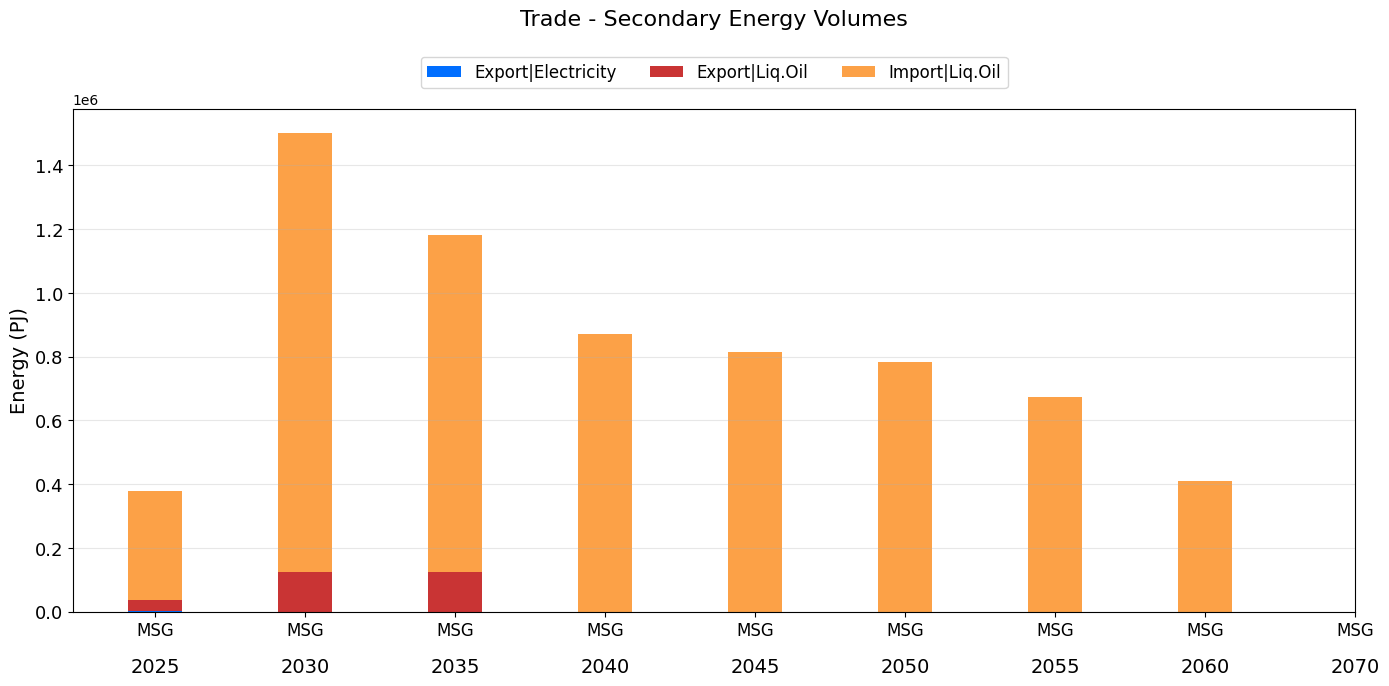

In [71]:
vars_trade_SE = [
    'Trade|Gross Export|Secondary Energy|Electricity|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume',
]
colors_trade_SE = {
    'Trade|Gross Export|Secondary Energy|Electricity|Volume':       '#006eff',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume':   '#2d7a2d',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume':      '#2E2D2D',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume':       '#c93434',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume':       '#26d5e9',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume':   '#63b163',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume':      '#787878',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume':       '#FCA147',
}
labels_trade_SE = {
    'Trade|Gross Export|Secondary Energy|Electricity|Volume':       'Export|Electricity',
    'Trade|Gross Export|Secondary Energy|Liquids|Biomass|Volume':   'Export|Liq.Biomass',
    'Trade|Gross Export|Secondary Energy|Liquids|Coal|Volume':      'Export|Liq.Coal',
    'Trade|Gross Export|Secondary Energy|Liquids|Oil|Volume':       'Export|Liq.Oil',
    'Trade|Gross Import|Secondary Energy|Electricity|Volume':       'Import|Electricity',
    'Trade|Gross Import|Secondary Energy|Liquids|Biomass|Volume':   'Import|Liq.Biomass',
    'Trade|Gross Import|Secondary Energy|Liquids|Coal|Volume':      'Import|Liq.Coal',
    'Trade|Gross Import|Secondary Energy|Liquids|Oil|Volume':       'Import|Liq.Oil',
}

stacked_bar_comparison(vars_trade_SE, colors_trade_SE, labels_trade_SE,
                       'Trade - Secondary Energy Volumes')

## 16. Resource Extraction

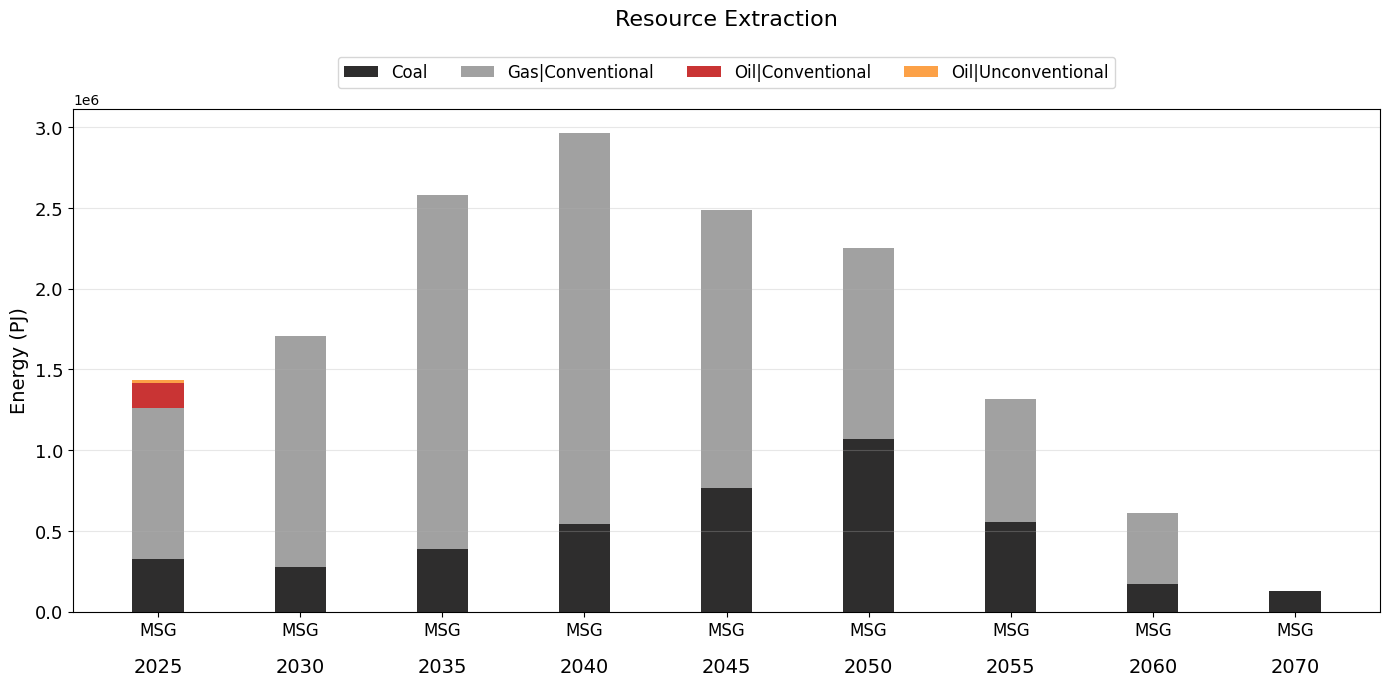

In [72]:
vars_res = [
    'Resource|Extraction|Coal',
    'Resource|Extraction|Gas|Conventional',
    'Resource|Extraction|Gas|Unconventional',
    'Resource|Extraction|Oil|Conventional',
    'Resource|Extraction|Oil|Unconventional',
]
colors_res = {
    'Resource|Extraction|Coal':                '#2E2D2D',
    'Resource|Extraction|Gas|Conventional':    '#A1A1A1',
    'Resource|Extraction|Gas|Unconventional':  '#787878',
    'Resource|Extraction|Oil|Conventional':    '#c93434',
    'Resource|Extraction|Oil|Unconventional':  '#FCA147',
}
labels_res = {
    'Resource|Extraction|Coal':                'Coal',
    'Resource|Extraction|Gas|Conventional':    'Gas|Conventional',
    'Resource|Extraction|Gas|Unconventional':  'Gas|Unconventional',
    'Resource|Extraction|Oil|Conventional':    'Oil|Conventional',
    'Resource|Extraction|Oil|Unconventional':  'Oil|Unconventional',
}

stacked_bar_comparison(vars_res, colors_res, labels_res, 'Resource Extraction')

In [ ]:
_cm_raw = pd.read_excel('../formatted/MESSAGEix-Pakistan_CM.xlsx')
_cm_raw.columns = _cm_raw.columns.astype(str)
_cm_raw = _cm_raw.loc[:, ~_cm_raw.columns.str.lower().str.startswith('unnamed:')]
cm = pyam.IamDataFrame(_cm_raw)

ue_sectors = ['Industry', 'Buildings', 'Transport', 'Non-Commercial Biomass']
ue_colors = {
    'Industry':               '#FCA147',
    'Buildings':              '#26d5e9',
    'Transport':              '#c93434',
    'Non-Commercial Biomass': '#63b163',
}
ue_vars = {
    'Industry': [
        'Useful Energy|Industrial Specific',
        'Useful Energy|Industrial Thermal',
        'Useful Energy|Feedstocks',
    ],
    'Buildings': [
        'Useful Energy|RC Specific',
        'Useful Energy|RC Thermal',
    ],
    'Transport': [
        'Useful Energy|Transport',
        'Useful Energy|Shipping',
    ],
    'Non-Commercial Biomass': [
        'Useful Energy|Non-Commercial Biomass',
    ],
}

fig, ax = plt.subplots(figsize=(14, 7))
w, gap_year = 0.9, 1.5
added, x = set(), 0
year_centers, bar_positions, bar_labels = [], [], []

for yi, year in enumerate(YEARS):
    if yi > 0:
        x += gap_year
    bottom = 0
    for sector in ue_sectors:
        val = 0
        for var in ue_vars[sector]:
            filt = cm.filter(variable=var, year=year)
            if not filt.empty:
                val += filt.timeseries().values[0][0] * 1000  # EJ -> PJ
        if val <= 0:
            continue
        lbl = sector if sector not in added else ''
        if lbl:
            added.add(sector)
        ax.bar(x, val, w, bottom=bottom, color=ue_colors[sector], label=lbl)
        bottom += val
    bar_positions.append(x)
    bar_labels.append(str(year))
    x += w + 0.1

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, fontsize=13)
ax.set_ylabel('Useful Energy (PJ)', fontsize=14)
ax.set_title('Useful Energy by Sector - Current Measures', fontsize=16, pad=20)
ax.tick_params(axis='y', labelsize=13)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()

## 17. Useful Energy by Sector